In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

Create SQLite Database and Table

Create Connection and Insert Data

In [14]:
import sqlite3
import pandas as pd

# (Re)connect to the database
conn = sqlite3.connect(':memory:')  # or 'sales.db' for a persistent file
cursor = conn.cursor()

# Create the table
cursor.execute('''
CREATE TABLE sales (
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

# Sample data
sample_data = [
    ("Apple", 10, 2.5),
    ("Banana", 20, 1.0),
    ("Apple", 5, 2.5),
    ("Orange", 15, 1.5)
]

# Insert data
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

# Display data
df = pd.read_sql_query("SELECT * FROM sales", conn)
df


,product,quantity,price
0,Apple,10,2.5
1,Banana,20,1.0
2,Apple,5,2.5
3,Orange,15,1.5


=>Query the Aggregated Data

In [17]:
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Display the result
df


,product,total_qty,revenue
0,Apple,15,37.5
1,Banana,20,20.0
2,Orange,15,22.5


Plot the bar chart

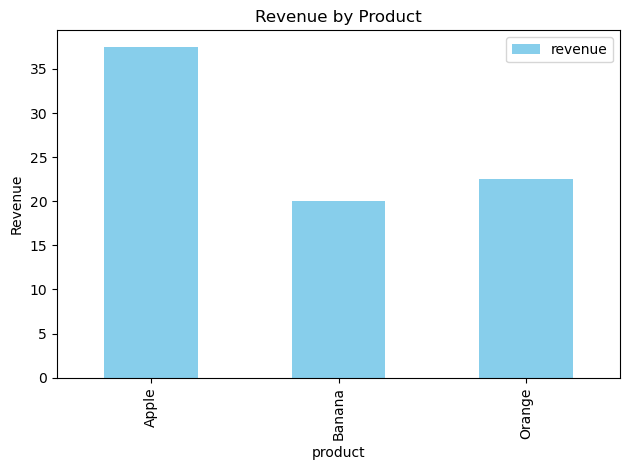

In [18]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='product', y='revenue', title="Revenue by Product", color='skyblue')
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")  
plt.show()


=>Sort Products By Revenue

In [20]:
df_sorted = df.sort_values(by="revenue", ascending=False)
print("Products Sorted by Revenue:\n", df_sorted)


Products Sorted by Revenue:
   product  total_qty  revenue
0   Apple         15     37.5
2  Orange         15     22.5
1  Banana         20     20.0


=> Bar Chart  With revenue